In [23]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [24]:
full=False
if full:
    remove_list = ['dft']
else:
    remove_list = ['dft', '7net-0', '7net-l3i5', '7net-omat']

In [25]:
df = pd.read_csv('/Users/yujinkang/omni.csv')

df

,DFT,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omc,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
0,0.470,0.704224,0.725830,0.401811,0.946671,0.603394,0.591064,0.523682,0.528076,0.599515,0.759837,-3.327481,0.658051,0.602661,0.747559,0.749512
1,-0.010,0.149780,0.176514,-0.040902,0.211581,-0.079468,-0.030273,-0.021484,-0.048462,0.060142,0.103535,0.036560,0.049103,0.011597,0.085449,0.093018
2,0.680,1.305420,1.343750,0.843394,1.596747,1.080322,1.158447,1.068848,1.078003,0.958472,1.234555,-0.951723,1.184586,1.050903,1.310303,1.348267
3,0.470,0.487915,0.529297,0.248817,0.956098,0.296753,0.306030,0.500366,0.501221,0.490735,0.554143,-0.047834,0.549438,0.323242,0.434448,0.440552
4,0.340,0.912598,0.935791,0.494987,1.166349,0.767456,0.761841,0.761230,0.754639,0.742437,0.893138,-0.918471,0.789307,0.798584,0.936523,0.941284
5,0.580,1.065186,1.098145,0.660470,1.284659,0.766846,0.781982,0.754639,0.762329,0.865548,1.082922,4.393798,0.949188,0.888428,1.048584,1.111450
6,0.120,0.622070,0.665039,0.177607,0.953133,0.286377,0.315430,0.358887,0.362183,0.865549,0.724986,4.393797,0.515427,0.465576,0.642944,0.674438
7,0.160,0.090088,0.092651,0.102144,0.102549,0.087402,0.110718,0.042725,0.031739,0.077767,0.104160,3.955577,0.109238,0.044434,0.073730,0.064575
8,0.130,0.092285,0.110107,0.158897,0.126573,0.043457,0.070435,-0.001587,0.001709,0.078711,0.130926,3.132078,0.071487,-0.019775,0.041504,0.047363
9,-0.090,-0.042969,-0.004761,0.015525,-0.120993,-0.030518,0.024170,-0.125610,-0.144653,-0.044352,0.032939,8.830279,-0.040085,-0.151001,-0.048096,-0.043457


In [26]:
# df.drop(columns=['solute'], inplace=True)
mlip_list = df.columns.tolist()
remove_list = ['DFT','UMA-omc']
for r in remove_list:
    mlip_list.remove(r)
    
for mlip in mlip_list:
    df[mlip+'_delta'] = df[mlip] - df['DFT']
df.to_csv('/Users/yujinkang/omni_delta.csv', index=False)
df.reset_index(inplace=True)

In [27]:
sns_df = pd.DataFrame(columns=['index','DFT', 'mlip', 'pred','delta','abs_error'], index=range(len(mlip_list)*len(df)))
idx = 0
for i in range(len(df)):
    for mlip in mlip_list:
        sns_df.loc[idx, 'index'] = i
        sns_df.loc[idx, 'DFT'] = df.loc[i, 'DFT']
        sns_df.loc[idx, 'mlip'] =  mlip
        sns_df.loc[idx, 'pred'] = df.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = df.loc[i, mlip+'_delta']
        sns_df.loc[idx, 'abs_error'] = abs(df.loc[i, mlip+'_delta'])
        idx += 1
sns_df.to_csv('/Users/yujinkang/sns.csv', index=False)

In [28]:
error_df = pd.DataFrame(columns = mlip_list)
true_value = df['DFT']
for col in mlip_list:
    pred_value = df[col]
    error_df.loc['MAE', col] = mean_absolute_error(true_value, pred_value)
    error_df.loc['MSE', col] = mean_squared_error(true_value, pred_value)
    error_df.loc['RMSE', col] = np.sqrt(mean_squared_error(true_value, pred_value))
    error_df.loc['R2', col] = r2_score(true_value, pred_value)
    # error_df.loc['Explained Variance', col] = explained_variance_score(true_value, pred_value)
    error_df.loc['MAPE', col] = mean_absolute_percentage_error(true_value, pred_value)

error_df.to_csv('/Users/yujinkang/error.csv', index=True)
error_df



,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
MAE,0.160421,0.173075,0.153445,0.272686,0.13039,0.125104,0.111582,0.105569,0.155057,0.189861,0.126323,0.138274,0.166237,0.182019
MSE,0.060766,0.068893,0.043707,0.156574,0.031104,0.028964,0.023429,0.023119,0.055253,0.072095,0.03806,0.037613,0.064643,0.074389
RMSE,0.246507,0.262475,0.209062,0.395694,0.176363,0.170187,0.153065,0.152051,0.235059,0.268506,0.195088,0.193941,0.25425,0.272743
R2,0.825184,0.801803,0.87426,0.549556,0.910518,0.916675,0.932598,0.933488,0.841044,0.79259,0.890507,0.891792,0.814029,0.785992
MAPE,1.292878,1.457187,0.779041,2.048563,0.815913,0.664941,0.595565,0.61804,0.912047,1.224259,0.753644,0.596773,1.039373,1.128126


In [37]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 3

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'in'

plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.05
plt.rcParams['figure.subplot.hspace'] = 0.03



In [38]:
error_df

,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
MAE,0.160421,0.173075,0.153445,0.272686,0.13039,0.125104,0.111582,0.105569,0.155057,0.189861,0.126323,0.138274,0.166237,0.182019
MSE,0.060766,0.068893,0.043707,0.156574,0.031104,0.028964,0.023429,0.023119,0.055253,0.072095,0.03806,0.037613,0.064643,0.074389
RMSE,0.246507,0.262475,0.209062,0.395694,0.176363,0.170187,0.153065,0.152051,0.235059,0.268506,0.195088,0.193941,0.25425,0.272743
R2,0.825184,0.801803,0.87426,0.549556,0.910518,0.916675,0.932598,0.933488,0.841044,0.79259,0.890507,0.891792,0.814029,0.785992
MAPE,1.292878,1.457187,0.779041,2.048563,0.815913,0.664941,0.595565,0.61804,0.912047,1.224259,0.753644,0.596773,1.039373,1.128126


In [31]:

color_dict= {
    'ompa-omat': '#02baae',
    'ompa-mpa': '#72b8b3',
    'omni-omat': '#0073ff',
    'omni-mpa': '#8cbbf5',
    'omni-matpes_pbe': '#0047b3',
    'ORB-omat': '#d48f3f',
    'ORB-mpa': '#d9ba98',
    'eSEN-omat':'#e8d803',
    'eSEN-oam': '#f5ea74',
    'DPA-mp': '#d19adf',
    'DPA-omat': '#e829f6',
    'UMA-omat': '#ff0000',
    'UMA-omc': '#ff7f7f',
    'MACE-omat': '#00b300',
    'MACE-mpa': '#66ff66',
}


In [44]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(15,6.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(filename, transparent=True)
    # plt.close()
    plt.show()
    print(f'Box plot saved as {filename}')


In [52]:
def plot_violin(sns_df, filename):
    plt.figure(figsize=(15,5.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]

    sns.violinplot(
        data=sns_df,
        x="mlip",
        y="delta",          
        inner="quartile",
        cut=0,
        palette=color_dict
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
    
    # sns.despine()
    
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tight_layout()
    plt.savefig(filename, transparent=True)
    plt.show()

    print(f'Violin plot saved as {filename}')


/var/folders/1w/64l349yd0h51v7s1g8dcxzpr0000gn/T/ipykernel_20234/389051112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


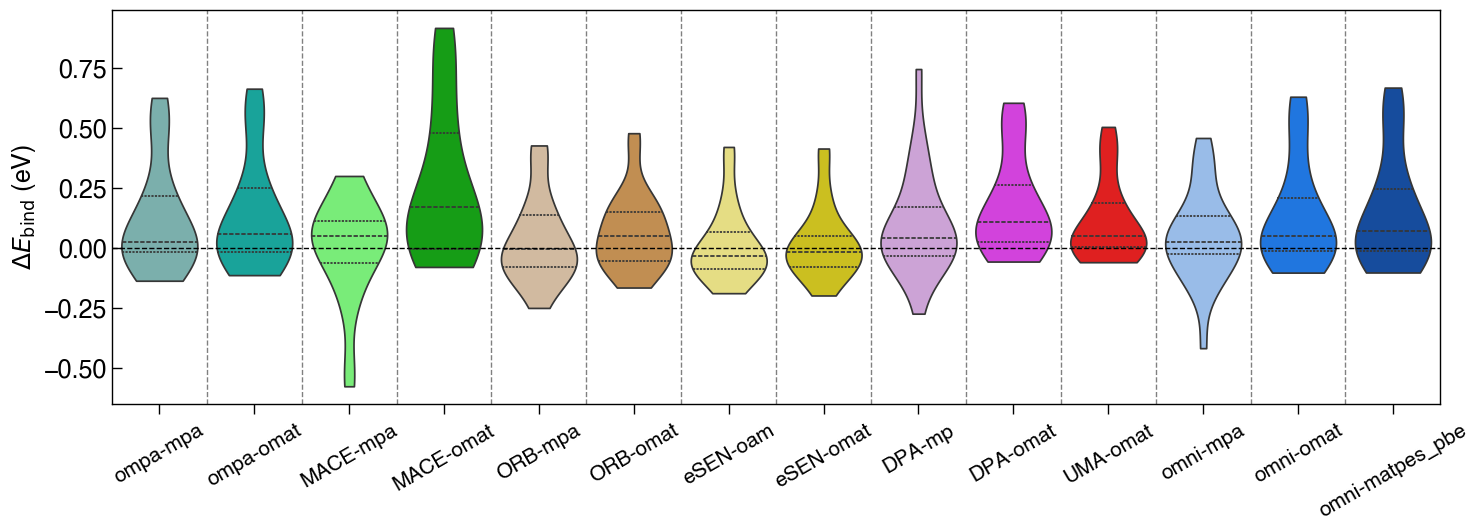

Violin plot saved as /Users/yujinkang/violin.png


In [53]:
plot_violin(sns_df, '/Users/yujinkang/violin.png')

/var/folders/1w/64l349yd0h51v7s1g8dcxzpr0000gn/T/ipykernel_20234/2612590933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


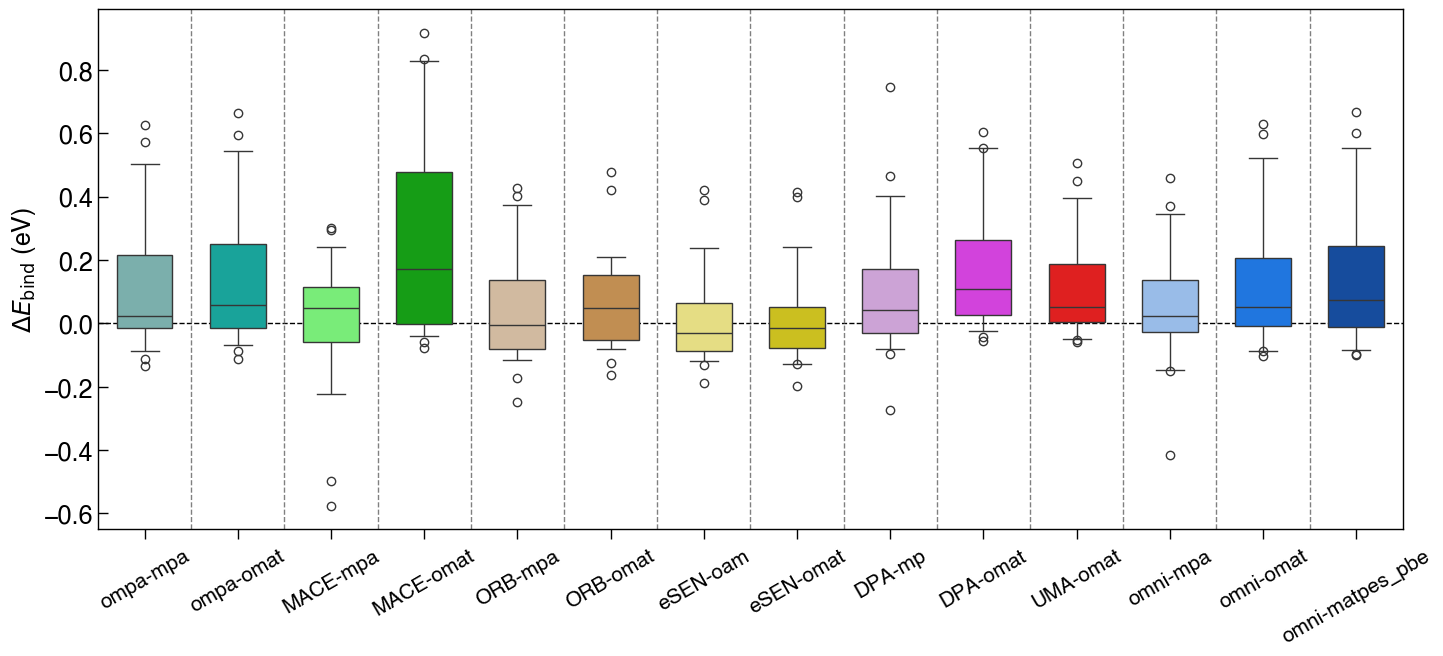

Box plot saved as /Users/yujinkang/box.png


In [47]:
plot_box(sns_df, '/Users/yujinkang/box.png')